In [1]:
import h5py
from matplotlib import pyplot as plt, rcParams
from matplotlib.colors import LogNorm
import numpy as np

%matplotlib inline

In [2]:
rcParams['axes.labelsize'] = 12
rcParams['figure.titlesize'] = 'xx-large'
np.set_printoptions(formatter={'float': lambda x: f'{x:.4e}'})

# Data from https://zenodo.org/records/4068485

## Meta-Data

`periods`:
- shape: (201,)
- units: seconds
- descr: the edges of the bins in observed orbital period from which the population was sampled.

`counts`:
- shape: (200,)
- units: None
- descr: The number of binaries produced in each period bin.  This number for each bin is capped at 500,000.  The sum of these values equals the total number of samples (70622013).


## Data
In this particular realization of data, the number of sampled binaries is `S = 70622013`.

`mtot`:
- shape: (S,)
- units: grams
- descr: the total mass of each binary (`M = M1 + M2`).

`mrat`:
- shape: (S,)
- units: None
- descr: The mass ratio of each binary, `q = M2/M1 <= 1.0`, where M2 is the mass of the secondary (lower mass) component.

`pobs`:
- shape: (S,)
- units: seconds
- descr: The orbital period of each binary in the observer's rest frame (at redshift, `z = 0`).

`redz`:
- shape: (S,)
- units: None
- descr: The redshift of each binary.

`weights`:
- shape: (S,)
- units: None
- descr: The number of 'true' binaries (i.e. the number that are expected to occur in this realization of an observed universe) represented by this individual 'sample', and having similar binary parameters.


In [3]:
f = h5py.File('kde-data.hdf5', 'r')
f.keys()
    

<KeysViewHDF5 ['counts', 'mrat', 'mtot', 'periods', 'pobs', 'redz', 'weights']>

In [4]:
counts = f['counts'][:]
mrat = f['mrat'][:]
mtot = f['mtot'][:] / 1.989e33 # convert g to M_sun
periods = f['periods'][:] 
pobs = f['pobs'][:]
redz = f['redz'][:]
weights = f['weights'][:]

verify `counts` by binning `pobs` using edges in `periods`

In [5]:
hist, *_ = np.histogram(pobs, bins=np.flip(periods))  # has to be monotonically increasing bins
print(np.sum(hist))
print(np.sum(counts))
np.array_equal(np.flip(hist), counts)

70622013
70622013


True

In [6]:
pobs /= 3.154e7 # convert s to yr

total number of samples in this dataset

In [7]:
num_samples = np.sum(weights)
np.format_float_scientific(num_samples)

'2.921476922e+09'

In [8]:
def make_hist2d(fig, ax, x, y, bins=200, xlogscale=False, ylogscale=False, clabel=None):
    xbins = bins
    ybins = bins
    if xlogscale:
        xbins = np.logspace(
            np.log10(x.min()),
            np.log10(x.max()),
            bins + 1
        )
    if ylogscale:
        ybins = np.logspace(
            np.log10(y.min()),
            np.log10(y.max()),
            bins + 1
        )

    H, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=[xbins, ybins],
        weights=weights
    )

    if xlogscale:
        ax.set_xscale('log')
        dx = np.diff(np.log10(xedges))
    else:
        dx = np.diff(xedges)
    if ylogscale:
        ax.set_yscale('log')
        dy = np.diff(np.log10(yedges))
    else:
        dy = np.diff(yedges)
    phi = H / (dx[:, None] * dy[None, :])

    pcm = ax.pcolormesh(
        xedges,
        yedges,
        phi.T,
        shading='auto',
        norm=LogNorm()
    )
    fig.colorbar(pcm, ax=ax,label=clabel)

    return dx[0], dy[0], phi






# Plotting total mass, z, and orbital period
$\phi$ colorbar is number density (normalized by bin width)

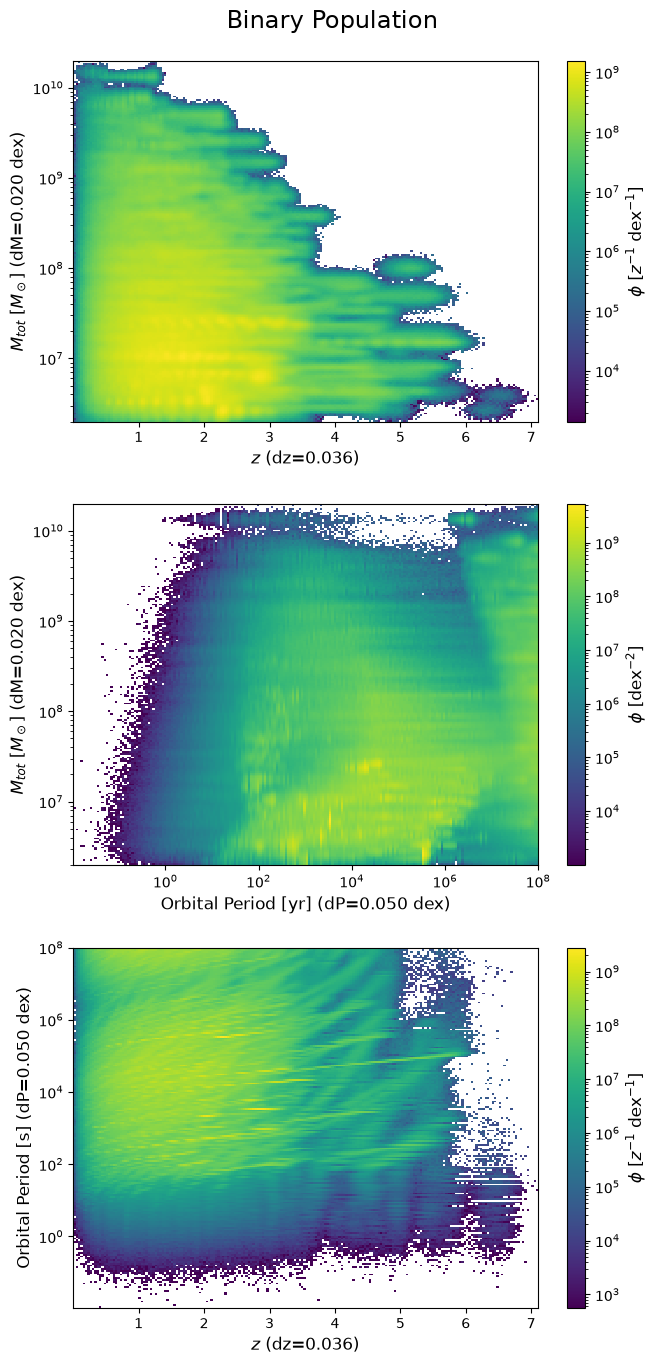

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(7,14))

fig.suptitle('Binary Population')

dz, dM, phi1 = make_hist2d(fig, ax[0], redz, mtot, ylogscale=True, clabel=r'$\phi$ [$z^{-1}$ dex$^{-1}$]')
ax[0].set_xlabel(rf'$z$ ({dz=:.3f})')
ax[0].set_ylabel(rf'$M_{{tot}}$ $[M_\odot$] ({dM=:.3f} dex)')

dP, _, phi2 = make_hist2d(fig, ax[1], pobs, mtot, xlogscale=True, ylogscale=True, clabel=r'$\phi$ [dex$^{-2}$]')
ax[1].set_xlabel(rf'Orbital Period [yr] ({dP=:.3f} dex)')
ax[1].set_ylabel(rf'$M_{{tot}}$ $[M_\odot$] ({dM=:.3f} dex)')

*_, phi3 = make_hist2d(fig, ax[2], redz, pobs, ylogscale=True, clabel=r'$\phi$ [$z^{-1}$ dex$^{-1}$]')
ax[2].set_xlabel(rf'$z$ ({dz=:.3f})')
ax[2].set_ylabel(rf'Orbital Period [s] ({dP=:.3f} dex)')

fig.tight_layout(pad=2)
plt.show()

analyzing the mean number densities of the first few z bins of plot 1 (z vs Mtot) to see if number density dropoff close to the y-axis is an artifact of color mapping...it doesn't appear to be

In [10]:
[np.format_float_scientific(np.mean(phi1[i,:])) for i in range(0,30)]

['3.508008085208089e+05',
 '2.0490949640062444e+06',
 '5.409729260294411e+06',
 '1.0613051337054176e+07',
 '1.740437902973871e+07',
 '2.582187908407211e+07',
 '3.5116632551068075e+07',
 '4.509249070006302e+07',
 '5.5928677015712954e+07',
 '6.91478796771697e+07',
 '8.28122901258012e+07',
 '9.538912480425398e+07',
 '1.0842629371452487e+08',
 '1.2146186806876402e+08',
 '1.3629850405948982e+08',
 '1.4907614574421394e+08',
 '1.6156803578919768e+08',
 '1.7475051895824733e+08',
 '1.8805427172376835e+08',
 '2.0273755037584582e+08',
 '2.1194908782809663e+08',
 '2.224904446065034e+08',
 '2.3362825707110634e+08',
 '2.4497485010315245e+08',
 '2.5996538477278352e+08',
 '2.6951447748859644e+08',
 '2.749413863306774e+08',
 '2.8190391713101906e+08',
 '2.921848054764889e+08',
 '3.006839535422341e+08']

In [11]:
def make_hist(fig, ax, x, masks):
    x_log = np.logspace(np.log10(mtot.min()), np.log10(mtot.max()), bins + 1)
    for mask in masks:
        ax.hist(x[mask], bins=x_log, histtype='step', weights=weights[mask]/weights.sum())
    ax.set_xscale('log')
    ax.set_yscale('log')

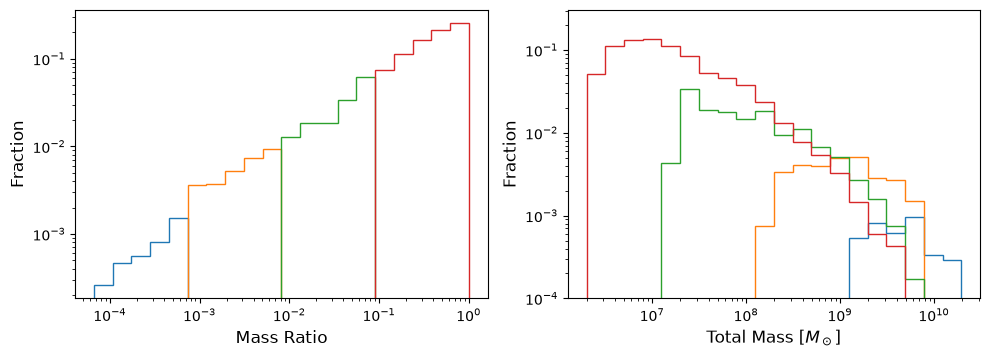

In [12]:
fig, ax = _, (mrat_hist, mtot_hist) = plt.subplots(1, 2, figsize=(10,4))

for a in ax.flat:
    a.set_box_aspect(0.7)

bins = 20
masks = []
mrat_log = np.logspace(np.log10(mrat.min()), np.log10(mrat.max()), bins + 1)
for i in range(4):
    start = i * bins // 4
    stop = start + bins // 4 + 1
    mrat_hist.hist(mrat, bins=mrat_log[start: stop], histtype='step', weights=weights/weights.sum())
    masks.append((mrat >= mrat_log[start]) & (mrat < mrat_log[stop-1]))
mrat_hist.set_xscale('log')
mrat_hist.set_yscale('log')
mrat_hist.set_xlabel('Mass Ratio')
mrat_hist.set_ylabel('Fraction')

make_hist(fig, mtot_hist, mtot, masks=masks)
mtot_hist.set_xlabel(r'Total Mass $[M_\odot]$')
mtot_hist.set_ylabel('Fraction')
mtot_hist.set_ylim(10e-5, None)

# make_hist(fig, pobs_hist, pobs, masks=masks)
# pobs_hist.set_xlabel('Orbital Period [yr]')
# pobs_hist.set_ylabel('Fraction')

# make_hist(fig, redz_hist, redz, masks=masks)
# redz_hist.set_xlabel(r'$z$')
# redz_hist.set_ylabel('Fraction')

fig.tight_layout()
plt.show()